In [18]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Flatten,Dropout
from tensorflow.keras.activations import relu,softmax
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [2]:
(ds_train, ds_test), ds_info = tfds.load(
    "kmnist",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)
#split=["train","test"] loads both Training data,Test data
#as_supervised = True mean Returns data as (image,label)
#with_info=True return Number of classes,Number of examples Image Shape Datasets description
print(ds_info)

tfds.core.DatasetInfo(
    name='kmnist',
    full_name='kmnist/3.0.1',
    description="""
    Kuzushiji-MNIST is a drop-in replacement for the MNIST dataset (28x28 grayscale, 70,000 images), provided in the original MNIST format as well as a NumPy format. Since MNIST restricts us to 10 classes, we chose one character to represent each of the 10 rows of Hiragana when creating Kuzushiji-MNIST.
    """,
    homepage='http://codh.rois.ac.jp/kmnist/index.html.en',
    data_dir='C:\\Users\\Shibam\\tensorflow_datasets\\kmnist\\3.0.1',
    file_format=tfrecord,
    download_size=20.26 MiB,
    dataset_size=31.76 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60

In [4]:
print(ds_info.features["label"].num_classes)

10


In [5]:
print(ds_info.features["image"].shape)

(28, 28, 1)


In [6]:
print(ds_info.splits["train"].num_examples)

60000


In [7]:
print(ds_info.splits["test"].num_examples)

10000


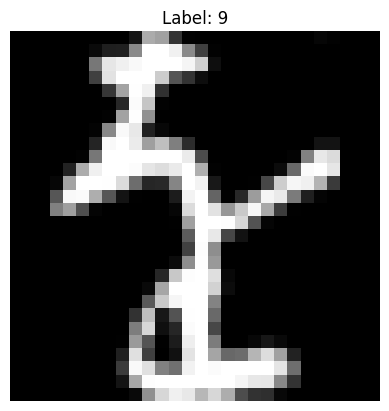

In [8]:
image, label = next(iter(ds_train))

plt.imshow(image.numpy().squeeze(), cmap="gray")
plt.title(f"Label: {label.numpy()}")
plt.axis("off")
plt.show()

In [9]:
print(label.numpy())

9


In [10]:
x_train = []
y_train = []
for image,label in ds_train:
    x_train.append(image.numpy())
    y_train.append(label.numpy())
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = []
y_test = []
for image,label in ds_test:
    x_test.append(image.numpy())
    y_test.append(label.numpy())
x_test = np.array(x_test)
y_test = np.array(y_test)

In [11]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [12]:
print(x_train.min())
print(x_train.max())

0.0
1.0


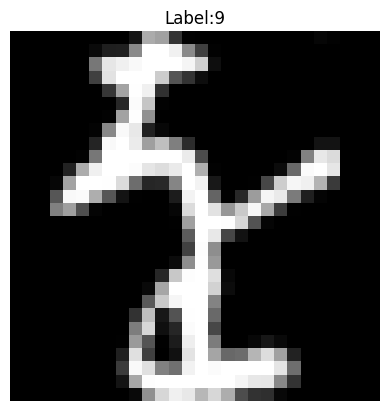

In [16]:
plt.imshow(x_train[0],cmap='gray')
plt.title(f"Label:{y_train[0]}")
plt.axis('off')
plt.show()

In [19]:
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (28,28,1)),
    MaxPool2D((2,2)),
    Conv2D(64,(3,3),activation = 'relu'),
    MaxPool2D((2,2)),
    Flatten(),
    Dense(64,activation = 'relu'),
    Dense(10,activation = 'softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history = model.fit(x_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.2)

C:\Users\Shibam\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9011 - loss: 0.3255 - val_accuracy: 0.9481 - val_loss: 0.1669
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9662 - loss: 0.1122 - val_accuracy: 0.9714 - val_loss: 0.0946
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9789 - loss: 0.0713 - val_accuracy: 0.9744 - val_loss: 0.0866
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9856 - loss: 0.0458 - val_accuracy: 0.9698 - val_loss: 0.1027
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9898 - loss: 0.0324 - val_accuracy: 0.9763 - val_loss: 0.0859
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9925 - loss: 0.0230 - val_accuracy: 0.9784 - val_loss: 0.0867
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9942 - loss: 0.0168 - val_accuracy: 0.9783 - val_loss: 0.0869
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9955 - loss: 0.0142 - 

In [20]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)
print("Test Loss:",test_loss*100)
print("Test Accuracy:",test_accuracy*100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9477 - loss: 0.2761
Test Loss: 27.6054710149765
Test Accuracy: 94.7700023651123


In [21]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
predicted_labels = np.argmax(predictions,axis = 1)
print("Predicted:")
print(predicted_labels[:10])
print("Actual:")
print(y_test[:10])

Predicted:
[5 9 7 7 6 0 0 0 6 6]
Actual:
[5 9 7 7 6 0 0 0 6 6]


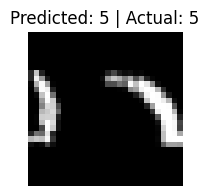

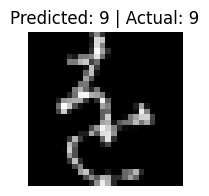

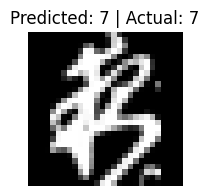

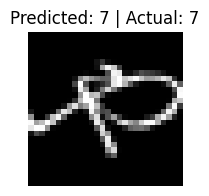

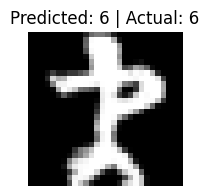

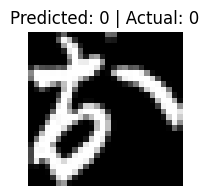

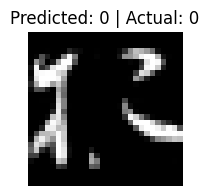

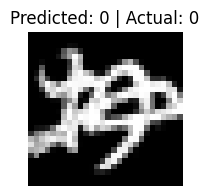

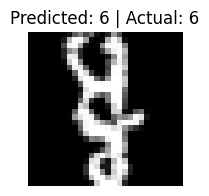

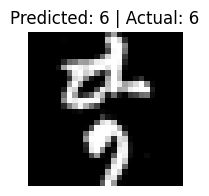

In [26]:
for i in range(10):
    plt.figure(figsize=(15,2))
    plt.imshow(x_test[i],cmap = 'gray')
    plt.title(f"Predicted: {predicted_labels[i]} | Actual: {y_test[i]}")
    plt.axis('off')
    plt.show()

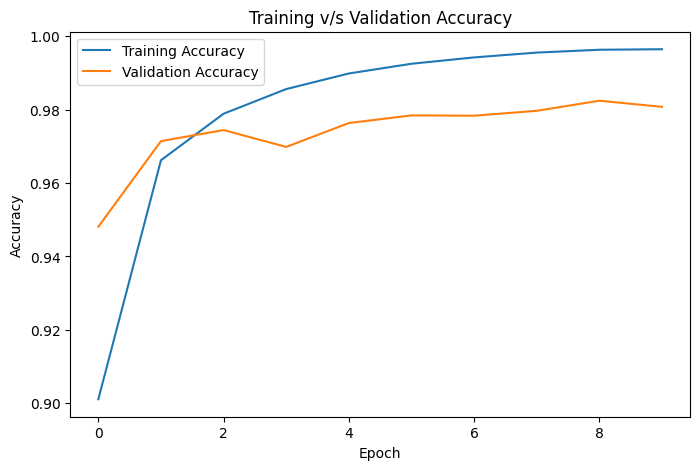

In [28]:
plt.figure(figsize = (8,5))
plt.plot(history.history['accuracy'],label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title("Training v/s Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

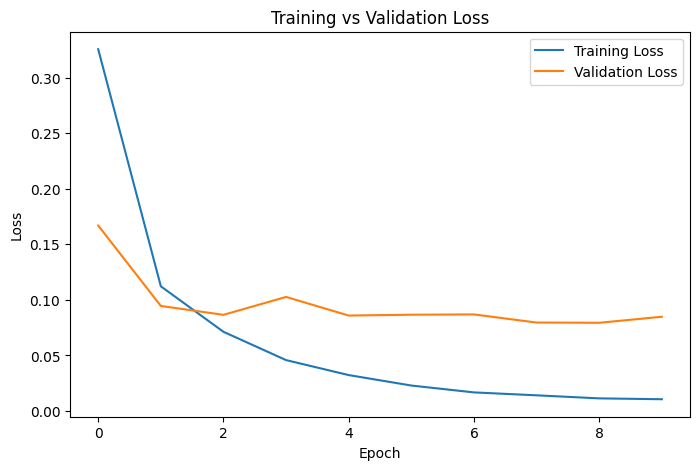

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

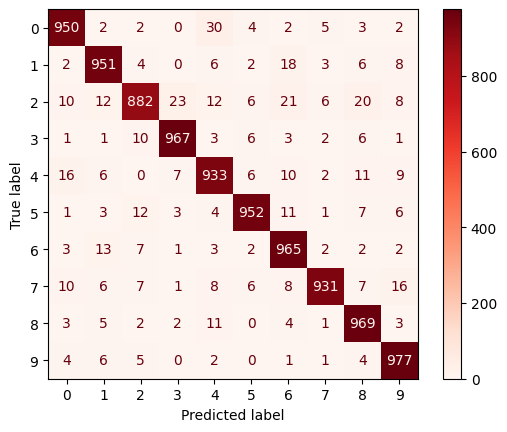

In [31]:
cm = confusion_matrix(y_test,predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Reds')
plt.show()

In [32]:
print(classification_report(y_test,predicted_labels))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1000
           1       0.95      0.95      0.95      1000
           2       0.95      0.88      0.91      1000
           3       0.96      0.97      0.97      1000
           4       0.92      0.93      0.93      1000
           5       0.97      0.95      0.96      1000
           6       0.93      0.96      0.94      1000
           7       0.98      0.93      0.95      1000
           8       0.94      0.97      0.95      1000
           9       0.95      0.98      0.96      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



In [33]:
wrong = np.where(predicted_labels != y_test)[0]

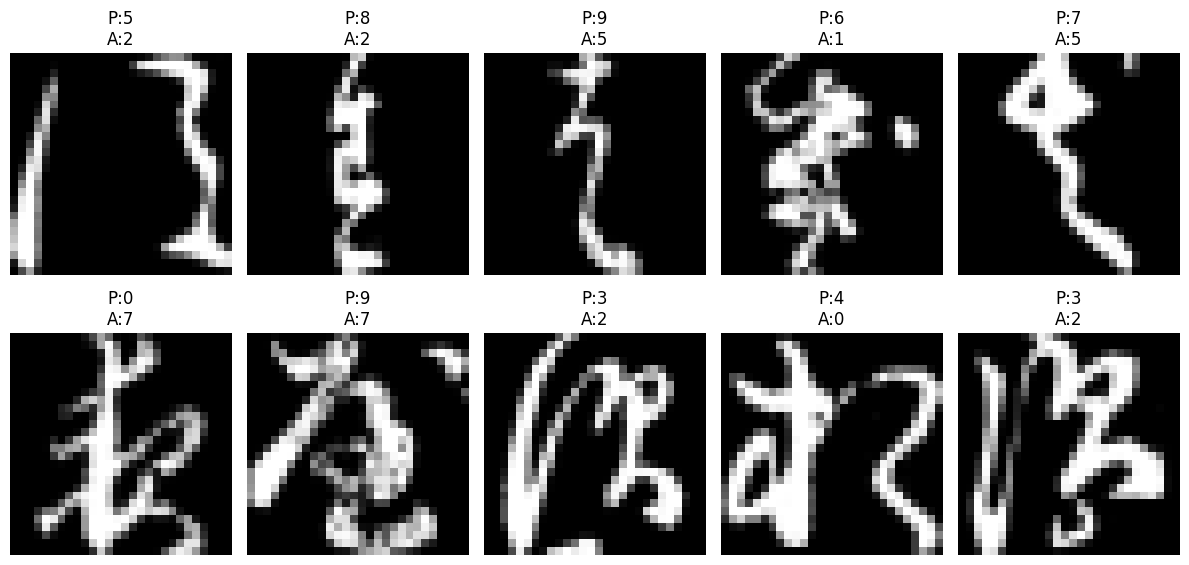

In [37]:
plt.figure(figsize=(12,6))

for i, idx in enumerate(wrong[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(
        f"P:{predicted_labels[idx]}\nA:{y_test[idx]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print("Training Accuracy :", train_acc)
print("Validation Accuracy:", val_acc)
if train_acc - val_acc > 0.05:
    print("Model may be overfitting.")
else:
    print("Model is generalizing well.")

Training Accuracy : 0.9964374899864197
Validation Accuracy: 0.9807500243186951
Model is generalizing well.
